# RF Fingerprinting — Preprocessing Pipeline
**Thesis:** Lightweight Device Authentication in Wireless Communication Using RF Fingerprinting  
**Authors:** Amitha · Tharangi Madushani  
**Supervisor:** Prof. Qinghua Wang  

---

## What this notebook does

For each recording (Session 1 + Session 2, both devices, all 4 modulations, 5 reps each):

1. **Load** `.dat` file as `complex64` IQ samples  
2. **Drop** first 100,000 samples (power-on transient artefact)  
3. **Normalise** by max absolute amplitude — no mean subtraction (preserves DC offset / CFO fingerprint)  
4. **Segment** into non-overlapping 128-sample windows → shape `(N, 128, 2)` where axis-2 = [I, Q]  
5. **Label**: DEV01 = 0, DEV02 = 1  
6. **Inject AWGN** offline at SNR = ∞ (clean), 20, 10, 0 dB  
7. **Save** `.npy` pairs per modulation × SNR × session  

---

## Output structure

```
MyDrive/My Thesis/Preprocessed/
├── S1/
│   ├── BPSK_clean_X.npy   shape: (N, 128, 2)  float32
│   ├── BPSK_clean_y.npy   shape: (N,)          int32
│   ├── BPSK_SNR0_X.npy
│   ├── BPSK_SNR0_y.npy
│   ├── BPSK_SNR10_X.npy
│   ├── BPSK_SNR10_y.npy
│   ├── BPSK_SNR20_X.npy
│   ├── BPSK_SNR20_y.npy
│   └── ... (same for QPSK, GFSK, OOK)
└── S2/
    └── ... (same structure)
```

## Section 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


## Section 2 — Configuration

**Edit only this cell** if your folder paths change.

In [1]:
import os

# ── Recording directories ──────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/My Thesis'
MAX_WINDOWS_PER_REP = 10_000

SESSION_DIRS = {
    'S1': os.path.join(BASE, 'Recordings', 'Recordings_Mod'),
    'S2': os.path.join(BASE, 'Recordings', 'Recordings_Mod_s2'),
}

# ── Output directory ───────────────────────────────────────────────────────────
OUTPUT_BASE = os.path.join(BASE, 'Preprocessed')

# ── Experiment parameters ──────────────────────────────────────────────────────
DEVICES      = ['DEV01', 'DEV02']           # DEV01 → label 0, DEV02 → label 1
MODULATIONS  = ['BPSK', 'QPSK', 'GFSK', 'OOK']
N_REPS       = 5                            # 5 recordings per device per modulation
SNR_LEVELS   = [None, 20, 10, 0]           # None = clean (no noise added)

# ── Preprocessing constants ────────────────────────────────────────────────────
DROP_SAMPLES  = 100_000                    # drop power-on transient
WINDOW_SIZE   = 128                        # IQ samples per CNN input window
DTYPE_IN      = 'complex64'               # .dat file format

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_SEED = 42

print('Configuration loaded.')
print(f'  Sessions    : {list(SESSION_DIRS.keys())}')
print(f'  Modulations : {MODULATIONS}')
print(f'  SNR levels  : {["clean" if s is None else f"{s} dB" for s in SNR_LEVELS]}')
print(f'  Window size : {WINDOW_SIZE} samples')
print(f'  Drop        : first {DROP_SAMPLES:,} samples per file')

Configuration loaded.
  Sessions    : ['S1', 'S2']
  Modulations : ['BPSK', 'QPSK', 'GFSK', 'OOK']
  SNR levels  : ['clean', '20 dB', '10 dB', '0 dB']
  Window size : 128 samples
  Drop        : first 100,000 samples per file


## Section 3 — Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import time

np.random.seed(RANDOM_SEED)

print('Imports OK.')
print(f'NumPy version: {np.__version__}')

Imports OK.
NumPy version: 2.0.2


## Section 4 — Helper Functions

In [3]:
def load_and_normalise(filepath: str, drop: int = DROP_SAMPLES) -> np.ndarray:
    """
    Load a complex64 .dat recording, drop the power-on transient,
    and normalise by maximum absolute amplitude.

    No mean subtraction — preserves DC offset which encodes CFO fingerprint.

    Returns
    -------
    np.ndarray  complex64, amplitude in [-1, 1]
    """
    raw = np.fromfile(filepath, dtype=np.complex64)
    raw = raw[drop:]                           # drop transient
    max_amp = np.max(np.abs(raw))
    if max_amp == 0:
        raise ValueError(f'Zero-power signal detected in: {filepath}')
    raw = raw / max_amp                        # normalise — no mean subtraction
    return raw


def segment_iq(signal: np.ndarray, window: int = WINDOW_SIZE) -> np.ndarray:
    """
    Segment a complex IQ signal into non-overlapping windows.

    Parameters
    ----------
    signal  : complex64 array of shape (N_samples,)
    window  : number of IQ samples per window (default 128)

    Returns
    -------
    np.ndarray  float32, shape (N_windows, window, 2)
                axis-2: [I channel, Q channel]
    """
    n_windows = len(signal) // window
    signal = signal[:n_windows * window]       # trim incomplete tail
    signal = signal.reshape(n_windows, window)
    # Stack I and Q as last axis → (N, 128, 2)
    X = np.stack([signal.real, signal.imag], axis=-1)
    return X.astype(np.float32)


def add_awgn(X: np.ndarray, snr_db) -> np.ndarray:
    """
    Inject complex AWGN into IQ windows at a target SNR.

    Noise power is computed per window from the actual signal power,
    so SNR is correctly defined even after normalisation.

    Parameters
    ----------
    X      : float32 array, shape (N, window, 2)
    snr_db : target SNR in dB. Pass None to return X unchanged (clean).

    Returns
    -------
    np.ndarray  float32, same shape as X
    """
    if snr_db is None:
        return X.copy()

    snr_linear = 10 ** (snr_db / 10.0)

    # Signal power per window: mean of I^2 + Q^2 across all samples and channels
    # shape: (N, 1, 1) for broadcasting
    signal_power = np.mean(X ** 2, axis=(1, 2), keepdims=True)

    # Noise power: P_noise = P_signal / SNR_linear
    # Split equally between I and Q → std = sqrt(P_noise / 2)
    noise_std = np.sqrt(signal_power / (2.0 * snr_linear))

    noise = noise_std * np.random.randn(*X.shape).astype(np.float32)
    return (X + noise).astype(np.float32)


def snr_label(snr_db) -> str:
    """Return a filename-safe SNR string: None → 'clean', 10 → 'SNR10'."""
    return 'clean' if snr_db is None else f'SNR{snr_db}'


print('Helper functions defined.')

Helper functions defined.


## Section 5 — Verify File Availability

Check all expected files exist before running the full pipeline.

In [4]:
missing = []
found   = []

for session, rec_dir in SESSION_DIRS.items():
    for mod in MODULATIONS:
        for dev in DEVICES:
            for rep in range(1, N_REPS + 1):
                fname = f'{dev}_{mod}_{session}_R{rep}.dat'
                fpath = os.path.join(rec_dir, fname)
                if os.path.exists(fpath):
                    size_mb = os.path.getsize(fpath) / 1e6
                    found.append((session, mod, dev, rep, size_mb))
                else:
                    missing.append(fpath)

print(f'Files found  : {len(found)}')
print(f'Files missing: {len(missing)}')

if missing:
    print('\n⚠  Missing files:')
    for p in missing:
        print(f'   {p}')
else:
    total_gb = sum(r[4] for r in found) / 1000
    print(f'\n✓ All {len(found)} files present  ({total_gb:.1f} GB total)')

Files found  : 80
Files missing: 0

✓ All 80 files present  (14.9 GB total)


## Section 6 — Main Preprocessing Loop

Processes all sessions × modulations × devices × reps.  
For each modulation × session, saves one `_X.npy` and `_y.npy` per SNR level.

**Expected output:** 2 sessions × 4 modulations × 4 SNR levels × 2 files = **64 .npy files**

In [5]:
# Create output directory structure
for session in SESSION_DIRS:
    Path(os.path.join(OUTPUT_BASE, session)).mkdir(parents=True, exist_ok=True)

print('Output directories ready.')
print(f'Saving to: {OUTPUT_BASE}')

Output directories ready.
Saving to: /content/drive/MyDrive/My Thesis/Preprocessed


In [6]:
# ── Section 6a: Create output directories ─────────────────────────────────────

for session in SESSION_DIRS:
    Path(os.path.join(OUTPUT_BASE, session)).mkdir(parents=True, exist_ok=True)

print('Output directories ready.')
print(f'Saving to: {OUTPUT_BASE}')


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Section 6b: Main Preprocessing Loop                                        ║
# ║                                                                              ║
# ║  Subsampling cap: MAX_WINDOWS_PER_REP windows taken per .dat file.           ║
# ║  This keeps RAM usage manageable on Colab free tier (~12 GB limit).          ║
# ║                                                                              ║
# ║  With 5 reps × 2 devices × 10,000 cap → ~100,000 windows per modulation.    ║
# ║  That is more than sufficient for binary CNN classification.                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

MAX_WINDOWS_PER_REP = 10_000   # cap per .dat file — edit if you want more/fewer

stats = {}   # summary statistics collected for Section 7

t_total_start = time.time()

for session, rec_dir in SESSION_DIRS.items():
    print(f'\n══════════════════════════════════════════')
    print(f'  Session: {session}')
    print(f'══════════════════════════════════════════')
    out_dir = os.path.join(OUTPUT_BASE, session)

    for mod in MODULATIONS:
        print(f'\n  Modulation: {mod}')
        t_mod_start = time.time()

        windows_per_device = {}   # dev → (N_total, 128, 2) from all 5 reps

        for dev in DEVICES:
            rep_windows = []

            for rep in range(1, N_REPS + 1):
                fname = f'{dev}_{mod}_{session}_R{rep}.dat'
                fpath = os.path.join(rec_dir, fname)

                if not os.path.exists(fpath):
                    print(f'    ⚠  SKIP (not found): {fname}')
                    continue

                # Load, normalise, segment
                signal = load_and_normalise(fpath)
                X_rep  = segment_iq(signal)
                full_count = X_rep.shape[0]

                # ── Subsample if over the cap ──────────────────────────────────
                # Use a deterministic seed per rep so results are reproducible.
                # idx is sorted to preserve temporal order within the rep.
                if full_count > MAX_WINDOWS_PER_REP:
                    rng_sub = np.random.default_rng(RANDOM_SEED + rep)
                    idx     = rng_sub.choice(full_count, MAX_WINDOWS_PER_REP, replace=False)
                    idx.sort()
                    X_rep   = X_rep[idx]
                    cap_note = f'capped {MAX_WINDOWS_PER_REP:,} / {full_count:,}'
                else:
                    cap_note = f'{full_count:,} (under cap)'

                rep_windows.append(X_rep)
                print(f'    {fname}  →  {X_rep.shape[0]:,} windows  [{cap_note}]'
                      f'  ({os.path.getsize(fpath)/1e6:.1f} MB)')

            if not rep_windows:
                print(f'    ⚠  No reps found for {dev} {mod} {session} — skipping device.')
                continue

            windows_per_device[dev] = np.concatenate(rep_windows, axis=0)
            print(f'    {dev} total: {windows_per_device[dev].shape[0]:,} windows')

        # Both devices must be present to save anything
        if len(windows_per_device) < 2:
            print(f'  ⚠  Skipping {mod} {session} — not both devices present.')
            continue

        # Build combined X and y
        X_parts, y_parts = [], []
        for dev in DEVICES:
            lbl = 0 if dev == 'DEV01' else 1
            n   = windows_per_device[dev].shape[0]
            X_parts.append(windows_per_device[dev])
            y_parts.append(np.full(n, lbl, dtype=np.int32))

        X_clean = np.concatenate(X_parts, axis=0)   # (N_total, 128, 2)
        y_clean = np.concatenate(y_parts, axis=0)   # (N_total,)

        # Shuffle with fixed seed so device blocks are interleaved
        rng  = np.random.default_rng(RANDOM_SEED)
        perm = rng.permutation(len(y_clean))
        X_clean = X_clean[perm]
        y_clean = y_clean[perm]

        print(f'\n  Combined: {X_clean.shape}'
              f'  |  DEV01={np.sum(y_clean==0):,}  DEV02={np.sum(y_clean==1):,}')

        # Save one X/y pair per SNR level — process and discard immediately
        # to avoid holding multiple noisy copies in RAM at the same time
        for snr in SNR_LEVELS:
            tag    = snr_label(snr)
            X_noisy = add_awgn(X_clean, snr)          # new array, same shape

            x_path = os.path.join(out_dir, f'{mod}_{tag}_X.npy')
            y_path = os.path.join(out_dir, f'{mod}_{tag}_y.npy')

            np.save(x_path, X_noisy)
            np.save(y_path, y_clean)

            size_mb = os.path.getsize(x_path) / 1e6
            print(f'  Saved  {mod}_{tag}  X{X_noisy.shape}  ({size_mb:.1f} MB)')

            del X_noisy   # free immediately — don't accumulate in RAM

        # Free the clean array before moving to the next modulation
        del X_clean, y_clean
        import gc; gc.collect()

        stats[(session, mod)] = {
            'n_windows' : sum(v.shape[0] for v in windows_per_device.values()),
            'n_dev01'   : windows_per_device.get('DEV01', np.empty((0,))).shape[0],
            'n_dev02'   : windows_per_device.get('DEV02', np.empty((0,))).shape[0],
            'elapsed_s' : round(time.time() - t_mod_start, 1),
        }

        del windows_per_device
        gc.collect()

total_elapsed = time.time() - t_total_start
print(f'\n══════════════════════════════════════════')
print(f'✓ Preprocessing complete in {total_elapsed/60:.1f} min')
print(f'══════════════════════════════════════════')

Output directories ready.
Saving to: /content/drive/MyDrive/My Thesis/Preprocessed

══════════════════════════════════════════
  Session: S1
══════════════════════════════════════════

  Modulation: BPSK
    DEV01_BPSK_S1_R1.dat  →  10,000 windows  [capped 10,000 / 164,838]  (169.6 MB)
    DEV01_BPSK_S1_R2.dat  →  10,000 windows  [capped 10,000 / 199,935]  (205.5 MB)
    DEV01_BPSK_S1_R3.dat  →  10,000 windows  [capped 10,000 / 179,854]  (185.0 MB)
    DEV01_BPSK_S1_R4.dat  →  10,000 windows  [capped 10,000 / 197,003]  (202.5 MB)
    DEV01_BPSK_S1_R5.dat  →  10,000 windows  [capped 10,000 / 163,656]  (168.4 MB)
    DEV01 total: 50,000 windows
    DEV02_BPSK_S1_R1.dat  →  10,000 windows  [capped 10,000 / 190,580]  (196.0 MB)
    DEV02_BPSK_S1_R2.dat  →  10,000 windows  [capped 10,000 / 185,560]  (190.8 MB)
    DEV02_BPSK_S1_R3.dat  →  10,000 windows  [capped 10,000 / 175,790]  (180.8 MB)
    DEV02_BPSK_S1_R4.dat  →  10,000 windows  [capped 10,000 / 181,732]  (186.9 MB)
    DEV02_BPSK_S1

## Section 7 — Dataset Summary Table

In [7]:
print(f'{'Session':<8} {'Mod':<6} {'Total windows':>14} {'DEV01':>8} {'DEV02':>8} {'Time (s)':>9}')
print('-' * 58)
for (session, mod), s in sorted(stats.items()):
    print(f'{session:<8} {mod:<6} {s["n_windows"]:>14,} '
          f'{s["n_dev01"]:>8,} {s["n_dev02"]:>8,} {s["elapsed_s"]:>9.1f}')

Session  Mod     Total windows    DEV01    DEV02  Time (s)
----------------------------------------------------------
S1       BPSK          100,000   50,000   50,000      16.7
S1       GFSK          100,000   50,000   50,000      91.0
S1       OOK           100,000   50,000   50,000      78.8
S1       QPSK          100,000   50,000   50,000      87.9
S2       BPSK          100,000   50,000   50,000     111.4
S2       GFSK          100,000   50,000   50,000     102.0
S2       OOK           100,000   50,000   50,000      58.7
S2       QPSK          100,000   50,000   50,000      94.6


## Section 8 — Sanity Check: Load and Inspect One File

In [8]:
# Load the BPSK clean file from S1 as a quick sanity check
check_session = 'S1'
check_mod     = 'BPSK'
check_tag     = 'clean'

X_check = np.load(os.path.join(OUTPUT_BASE, check_session, f'{check_mod}_{check_tag}_X.npy'))
y_check = np.load(os.path.join(OUTPUT_BASE, check_session, f'{check_mod}_{check_tag}_y.npy'))

print(f'Loaded: {check_session}/{check_mod}_{check_tag}')
print(f'  X shape : {X_check.shape}   dtype: {X_check.dtype}')
print(f'  y shape : {y_check.shape}   dtype: {y_check.dtype}')
print(f'  X range : [{X_check.min():.4f}, {X_check.max():.4f}]')
print(f'  Class 0 (DEV01): {np.sum(y_check==0):,} windows')
print(f'  Class 1 (DEV02): {np.sum(y_check==1):,} windows')
print(f'  Balance ratio   : {np.sum(y_check==0)/len(y_check):.3f} / {np.sum(y_check==1)/len(y_check):.3f}')

Loaded: S1/BPSK_clean
  X shape : (100000, 128, 2)   dtype: float32
  y shape : (100000,)   dtype: int32
  X range : [-0.9877, 0.9858]
  Class 0 (DEV01): 50,000 windows
  Class 1 (DEV02): 50,000 windows
  Balance ratio   : 0.500 / 0.500


## Section 9 — Sanity Plots

Visual inspection of sample windows from each device — and noise effect comparison.

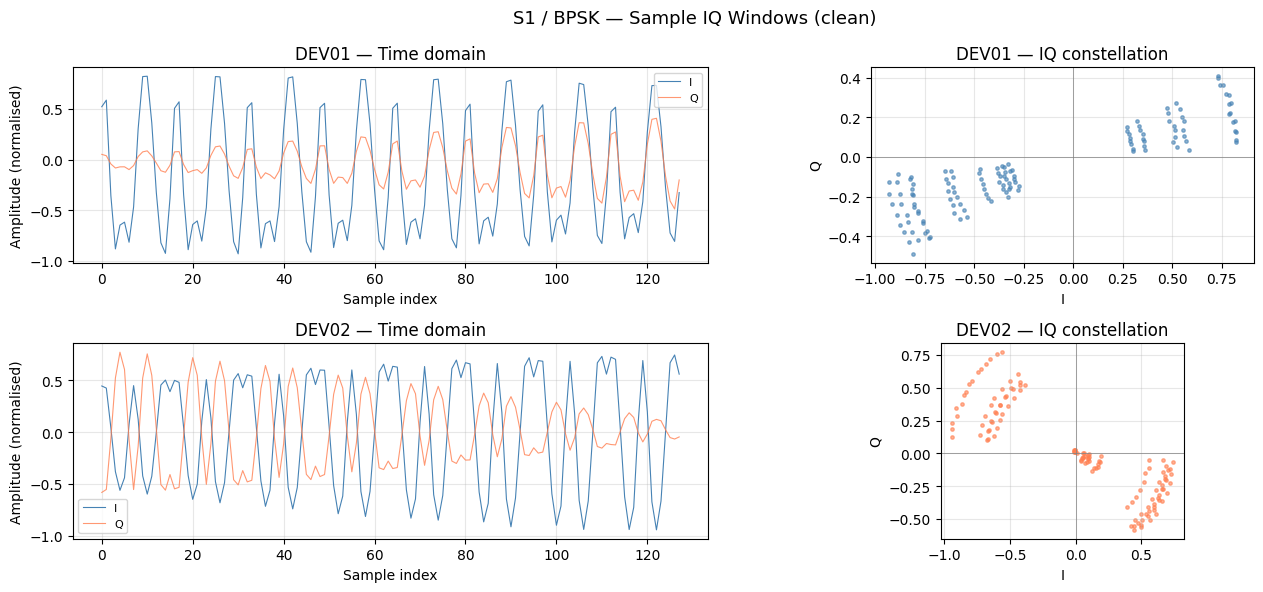

Plot saved.


In [9]:
# ── Plot 1: IQ windows from DEV01 and DEV02 (clean) ──────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle(f'{check_session} / {check_mod} — Sample IQ Windows (clean)', fontsize=13)

for row, (dev_label, dev_name) in enumerate([(0, 'DEV01'), (1, 'DEV02')]):
    idx = np.where(y_check == dev_label)[0][0]   # first window of this device
    window = X_check[idx]                          # (128, 2)

    # I/Q time series
    ax = axes[row, 0]
    ax.plot(window[:, 0], label='I', linewidth=0.8, color='steelblue')
    ax.plot(window[:, 1], label='Q', linewidth=0.8, color='coral', alpha=0.8)
    ax.set_title(f'{dev_name} — Time domain')
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Amplitude (normalised)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # IQ constellation
    ax = axes[row, 1]
    ax.scatter(window[:, 0], window[:, 1], s=6, alpha=0.6,
               color='steelblue' if dev_label == 0 else 'coral')
    ax.set_title(f'{dev_name} — IQ constellation')
    ax.set_xlabel('I')
    ax.set_ylabel('Q')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, f'{check_session}_{check_mod}_sample_windows.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

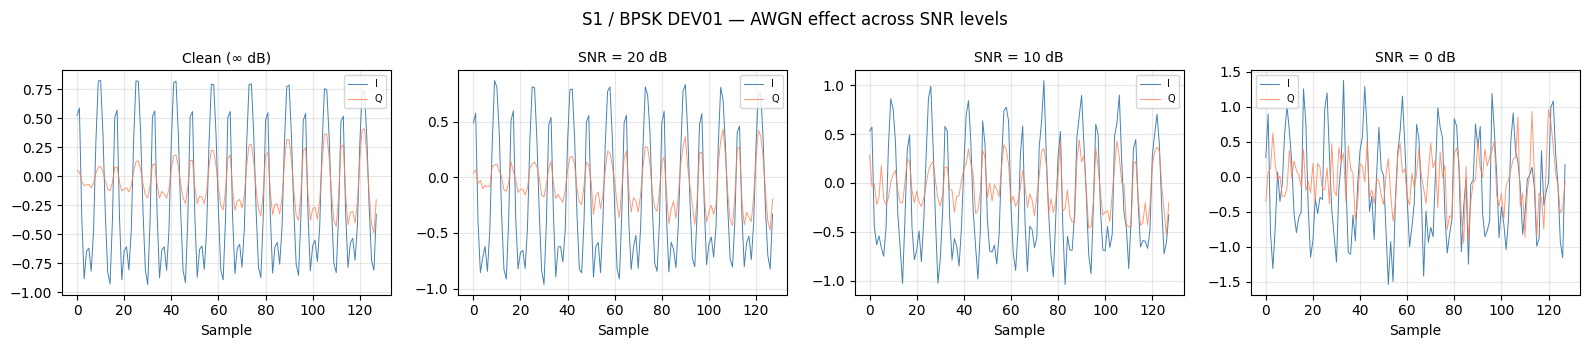

Plot saved.


In [10]:
# ── Plot 2: SNR comparison for DEV01 BPSK ─────────────────────────────────────

snr_tags  = ['clean', 'SNR20', 'SNR10', 'SNR0']
snr_vals  = [None, 20, 10, 0]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle(f'{check_session} / {check_mod} DEV01 — AWGN effect across SNR levels', fontsize=12)

dev0_idx = np.where(y_check == 0)[0][0]
clean_window = X_check[dev0_idx]   # (128, 2)

for ax, tag, snr in zip(axes, snr_tags, snr_vals):
    if snr is None:
        w = clean_window
    else:
        # Re-apply noise to the single window for illustration
        w = add_awgn(clean_window[np.newaxis], snr)[0]

    ax.plot(w[:, 0], label='I', linewidth=0.7, color='steelblue')
    ax.plot(w[:, 1], label='Q', linewidth=0.7, color='coral', alpha=0.8)
    title = 'Clean (∞ dB)' if snr is None else f'SNR = {snr} dB'
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Sample')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, f'{check_session}_{check_mod}_snr_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Section 10 — Cross-Session Verification

Confirm that S1 and S2 preprocessed files have comparable window counts (should be similar since recording duration and settings were identical).

In [11]:
print(f'{'Modulation':<12} {'S1 windows':>12} {'S2 windows':>12} {'Ratio S2/S1':>12}')
print('-' * 50)

for mod in MODULATIONS:
    s1_path = os.path.join(OUTPUT_BASE, 'S1', f'{mod}_clean_y.npy')
    s2_path = os.path.join(OUTPUT_BASE, 'S2', f'{mod}_clean_y.npy')

    if os.path.exists(s1_path) and os.path.exists(s2_path):
        n1 = len(np.load(s1_path))
        n2 = len(np.load(s2_path))
        ratio = n2 / n1
        flag = '  ✓' if 0.85 < ratio < 1.15 else '  ⚠ CHECK'
        print(f'{mod:<12} {n1:>12,} {n2:>12,} {ratio:>12.3f}{flag}')
    else:
        print(f'{mod:<12}   (missing — file not found)')

Modulation     S1 windows   S2 windows  Ratio S2/S1
--------------------------------------------------
BPSK              100,000      100,000        1.000  ✓
QPSK              100,000      100,000        1.000  ✓
GFSK              100,000      100,000        1.000  ✓
OOK               100,000      100,000        1.000  ✓


## Section 11 — File Index

Print a complete list of all output files with their sizes.

In [12]:
total_size = 0
all_files  = []

for session in SESSION_DIRS:
    out_dir = os.path.join(OUTPUT_BASE, session)
    for f in sorted(os.listdir(out_dir)):
        if f.endswith('.npy'):
            fpath = os.path.join(out_dir, f)
            size  = os.path.getsize(fpath)
            total_size += size
            all_files.append((session, f, size / 1e6))

print(f'{'Session':<8} {'File':<35} {'Size (MB)':>10}')
print('-' * 56)
for sess, fname, mb in all_files:
    print(f'{sess:<8} {fname:<35} {mb:>10.1f}')
print('-' * 56)
print(f'Total: {len(all_files)} files  |  {total_size/1e9:.2f} GB')

Session  File                                 Size (MB)
--------------------------------------------------------
S1       BPSK_SNR0_X.npy                          102.4
S1       BPSK_SNR0_y.npy                            0.4
S1       BPSK_SNR10_X.npy                         102.4
S1       BPSK_SNR10_y.npy                           0.4
S1       BPSK_SNR20_X.npy                         102.4
S1       BPSK_SNR20_y.npy                           0.4
S1       BPSK_clean_X.npy                         102.4
S1       BPSK_clean_y.npy                           0.4
S1       GFSK_SNR0_X.npy                          102.4
S1       GFSK_SNR0_y.npy                            0.4
S1       GFSK_SNR10_X.npy                         102.4
S1       GFSK_SNR10_y.npy                           0.4
S1       GFSK_SNR20_X.npy                         102.4
S1       GFSK_SNR20_y.npy                           0.4
S1       GFSK_clean_X.npy                         102.4
S1       GFSK_clean_y.npy                      

---

## ✓ Preprocessing Complete

### What was produced

```
Preprocessed/
├── S1/
│   ├── BPSK_clean_X.npy  (N, 128, 2) float32
│   ├── BPSK_clean_y.npy  (N,) int32
│   ├── BPSK_SNR0_X.npy
│   ├── BPSK_SNR0_y.npy
│   ├── BPSK_SNR10_X.npy
│   ├── BPSK_SNR10_y.npy
│   ├── BPSK_SNR20_X.npy
│   ├── BPSK_SNR20_y.npy
│   └── ... (QPSK, GFSK, OOK same pattern)
└── S2/
    └── ... (same)
```

### Next step: Experiment A CNN training

```python
# Loading snippet for the training notebook:
X = np.load('Preprocessed/S1/BPSK_clean_X.npy')   # (N, 128, 2)
y = np.load('Preprocessed/S1/BPSK_clean_y.npy')   # (N,)

# Temporal holdout split (first 70% train, last 30% test)
split = int(0.7 * len(y))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
```

> **Note:** Files were shuffled at the modulation level with a fixed seed (`RANDOM_SEED=42`).  
> For temporal holdout to be meaningful in the CNN notebook, reload the **unshuffled** version,  
> or set `RANDOM_SEED = None` and skip the shuffle step if strict temporal ordering is required.